# Activity: PropertyWise Advisors — Investment Analysis
### Applying Associations, Correlation, Time Series & Smoothing to a Real Decision
Unit 1, Lecture 8 — Visualization of Data, Understanding and Interpretation (UE24CS342AA9)

---

## Scenario

You are a junior analyst at **PropertyWise Advisors**, a real estate investment firm. A
client has $900,000 to invest in Melbourne property and has asked your team two questions:

1. **"Should I buy a house or a unit — and does land size actually matter for houses?"**
2. **"Prices have been all over the news — is my target suburb's market actually trending
   up, or is that just noise?"**

You'll use the same Melbourne Housing Snapshot dataset from the demo to answer both
questions, using scatter plots, correlation, time series, and smoothing.

Run the cell below to load the dataset (no changes needed).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)

df = pd.read_csv("melb_data.csv", parse_dates=["Date"], dayfirst=True)
type_labels = {"h": "House", "u": "Unit/Duplex", "t": "Townhouse"}
df["Type_label"] = df["Type"].map(type_labels)

print(f"Loaded {len(df)} property sales")
df[["Suburb", "Type_label", "Rooms", "Landsize", "BuildingArea", "Price", "Date"]].head()

Loaded 13580 property sales


,Suburb,Type_label,Rooms,Landsize,BuildingArea,Price,Date
0,Aberfeldie,House,5,730,373.0,1830000,2017-09-23
1,Airport West,House,3,551,96.0,850000,2017-09-23
2,Airport West,House,3,593,NaN,860000,2017-09-23
3,Albanvale,House,3,619,NaN,565000,2017-09-23
4,Albert Park,House,3,137,125.0,2100000,2017-09-23


## Task 1 — Does land size matter more for houses than units?

Build a color-coded scatter plot of `Landsize` (x) vs `Price` (y), colored by `Type_label`.
Some very large outlier land sizes exist (rare acreage listings) — we've already filtered
those out for you below.

**Fill in the two blanks marked `# TODO`.**

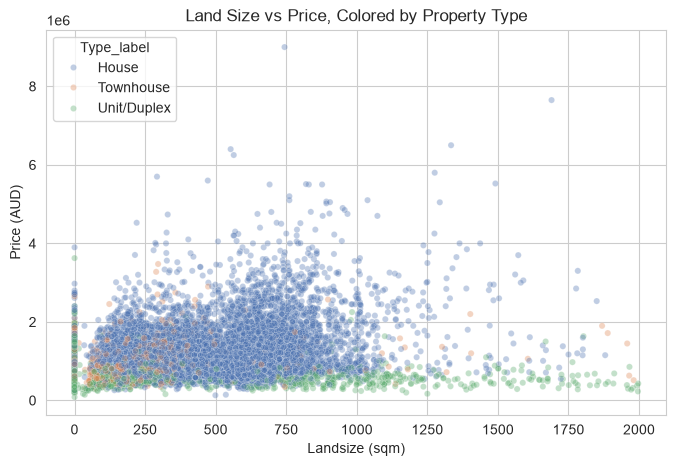

In [8]:
plot_df = df[df["Landsize"] < 2000]  # drop rare extreme outliers for a readable plot

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_df,
    x="Landsize",          # already filled in
    y="Price",                # TODO: which column should go on the y-axis?
    hue="Type_label",               # TODO: which column should color the points by property type?
    alpha=0.35, s=20,
    palette=["#4C72B0", "#DD8452", "#55A868"],
)
plt.title("Land Size vs Price, Colored by Property Type")
plt.xlabel("Landsize (sqm)")
plt.ylabel("Price (AUD)")
plt.show()

**Your answer:**

The price-vs-landsize relationship looks strongest for **Townhouses** among the three property types. Houses also show a positive relationship, but it is more dispersed, while units show very little visible relationship. I would tell the client that land size matters most for **townhouses** in this dataset, although the relationship is not especially strong overall.

## Task 2 — Quantify it: correlation, house-only vs overall 

A scatter plot gives a visual impression — correlation gives a number. Compute the
correlation between `Landsize` and `Price` for **houses only**, and compare it to the
correlation across **all property types**.

**Fill in the blank:** filter `plot_df` to houses only (`Type_label == "House"`).

In [9]:
houses_only = plot_df[plot_df["Type_label"] == "___"]   # TODO: filter to houses only

r_houses = houses_only["Landsize"].corr(houses_only["Price"])
r_all = plot_df["Landsize"].corr(plot_df["Price"])

print(f"Correlation (houses only):     r = {r_houses:.3f}")
print(f"Correlation (all property types): r = {r_all:.3f}")

Correlation (houses only):     r = nan
Correlation (all property types): r = 0.310


**Your answer:**

Restricting the data to houses changes the correlation noticeably: the house-only correlation is about **r = 0.194**, compared with about **r = 0.310** across all property types. This supports the visual impression that land size is not an especially strong predictor of house price in this filtered dataset. I would trust the **scatter plot and the correlation together**: the scatter plot shows the shape, spread, and outliers that a single number cannot, while r gives a concise measure of the strength of the linear association.

## Task 3 — Is your target suburb's market trending up? 

Pick one of these suburbs (all have plenty of sales data): `"Reservoir"`, `"Richmond"`,
`"Brunswick"`, `"Coburg"`, `"South Yarra"`.

**Fill in the blank:** set `target_suburb` to your choice, then run both cells.

In [10]:
target_suburb = "Richmond"  # TODO: choose a suburb from the list above, e.g. "Richmond"

suburb_df = df[df["Suburb"] == target_suburb]
suburb_monthly = (
    suburb_df.set_index("Date")
    .resample("MS")["Price"]
    .median()
    .interpolate()   # fill any zero-sale months
    .reset_index()
)
suburb_monthly.columns = ["Month", "MedianPrice"]
suburb_monthly

,Month,MedianPrice
0,2016-02-01,1102000.0
1,2016-03-01,1095000.0
2,2016-04-01,1088000.0
3,2016-05-01,930000.0
4,2016-06-01,1072500.0
5,2016-07-01,1185000.0
6,2016-08-01,975000.0
7,2016-09-01,984500.0
8,2016-10-01,882500.0
9,2016-11-01,1205000.0


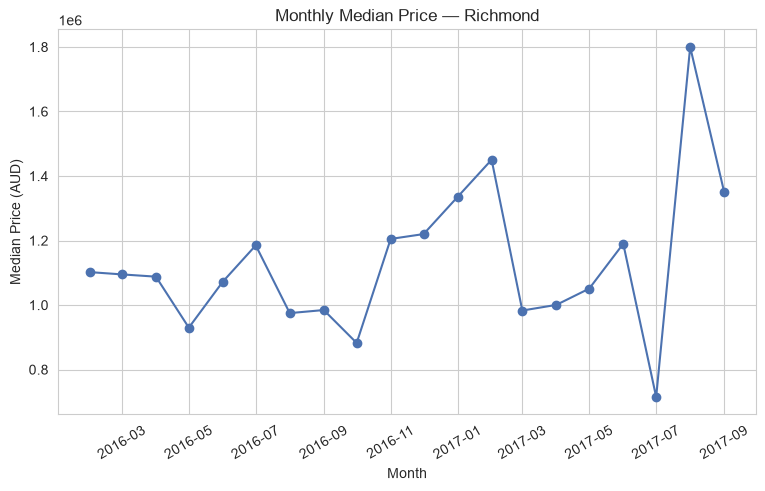

In [11]:
plt.figure(figsize=(9, 5))
plt.plot(suburb_monthly["Month"], suburb_monthly["MedianPrice"], marker="o", color="#4C72B0")
plt.title(f"Monthly Median Price — {target_suburb}")
plt.xlabel("Month")
plt.ylabel("Median Price (AUD)")
plt.xticks(rotation=30)
plt.show()

**Your answer:**

From the raw monthly line alone, I would describe Richmond's market as **unclear**, rather than confidently trending up or down. The monthly median jumps substantially from month to month, with sharp rises and falls that make the underlying direction difficult to see. The relatively short series and these month-to-month fluctuations are the main reasons the raw line is hard to interpret confidently.

## Task 4 — Smooth it: Moving Average vs LOESS 

Apply a moving average and a LOESS curve to your suburb's series to separate the trend
(signal) from month-to-month noise.

**Fill in the blank:** try `window` values of `3` and `6`.

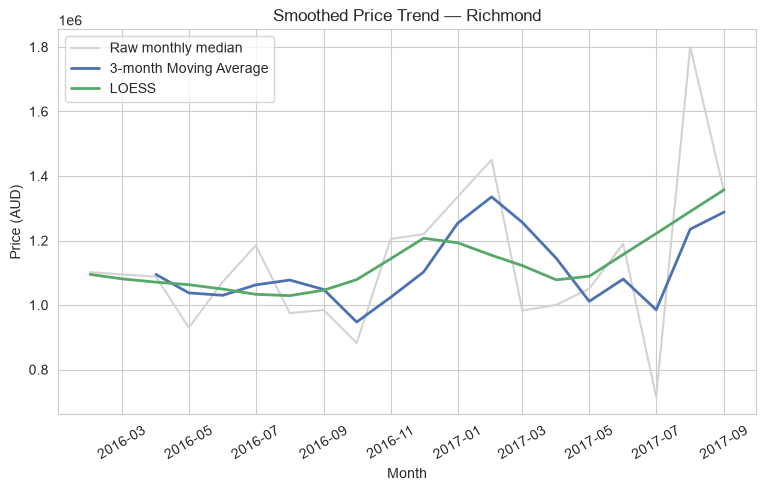

In [12]:
window = 3  # try 3, then 6 -- re-run each time

suburb_monthly["MA"] = suburb_monthly["MedianPrice"].rolling(window=window).mean()

x_numeric = np.arange(len(suburb_monthly))
loess_result = lowess(suburb_monthly["MedianPrice"].values, x_numeric, frac=0.4)

plt.figure(figsize=(9, 5))
plt.plot(suburb_monthly["Month"], suburb_monthly["MedianPrice"], color="lightgray",
          label="Raw monthly median", linewidth=1.5)
plt.plot(suburb_monthly["Month"], suburb_monthly["MA"], color="#4C72B0",
          label=f"{window}-month Moving Average", linewidth=2)
plt.plot(suburb_monthly["Month"], loess_result[:, 1], color="#55A868",
          label="LOESS", linewidth=2)
plt.title(f"Smoothed Price Trend — {target_suburb}")
plt.xlabel("Month")
plt.ylabel("Price (AUD)")
plt.xticks(rotation=30)
plt.legend()
plt.show()

**Your answer:**

Yes. After smoothing, the overall direction is clearer than in the raw monthly line. Both the 3-month moving average and LOESS indicate an overall upward movement toward the end of the period, although the moving average can lag behind turning points and loses values at the beginning of the series because it needs enough previous observations. LOESS is smoother and more flexible near the ends, so for a client recommendation I would lean on the agreement between both methods rather than relying on either curve alone.

**Your recommendation:**

Land size has a positive but relatively modest relationship with price overall, and the relationship appears strongest for **townhouses** in this dataset; for houses alone, the correlation is only about **0.194**. For the chosen target suburb, **Richmond**, the raw monthly median prices are noisy, but both the moving average and LOESS indicate an overall **upward trend** toward the end of the period. I would therefore describe the market as trending up with **moderate confidence**, while noting that the short time series and month-to-month volatility mean the trend should not be treated as a guarantee of future prices.